# Cleaning

In [34]:
import dagshub
import mlflow
import pandas as pd
import numpy as np
dagshub.init(repo_owner='kvizhmena11', repo_name='ML_assignment1_house_prices', mlflow=True)

mlflow.set_experiment("predicting_House_Prices_Modeling")
train_rdr = pd.read_csv('train.csv')
test_rdr = pd.read_csv('test.csv')
train_rdr.head()

Initialized MLflow to track repo "kvizhmena11/ML_assignment1_house_prices"

Repository kvizhmena11/ML_assignment1_house_prices initialized!

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [35]:
print(f"train size: {train_rdr.shape}")

hidden_vals = train_rdr.isnull().sum()
hidden_vals = hidden_vals[hidden_vals > 0].sort_values(ascending=False)

print(hidden_vals)

train size: (1460, 81)
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [36]:
cols_numed_train = train_rdr.select_dtypes(include=['int64', 'float64']).columns
cols_that_category_train = train_rdr.select_dtypes(include=['object']).columns

cols_numed_test = test_rdr.select_dtypes(include=['int64', 'float64']).columns
cols_that_category_test =test_rdr.select_dtypes(include=['object']).columns

train_rdr[cols_that_category_train] = train_rdr[cols_that_category_train].fillna("None")
test_rdr[cols_that_category_test] = test_rdr[cols_that_category_test].fillna("None")

train_rdr[cols_numed_train] = train_rdr[cols_numed_train].fillna(0)
test_rdr[cols_numed_test] = test_rdr[cols_numed_test].fillna(0)

print("empty strings in train : ", train_rdr.isnull().sum().max())
print("empty strings in test :", test_rdr.isnull().sum().max())

empty strings in train :  0
empty strings in test : 0


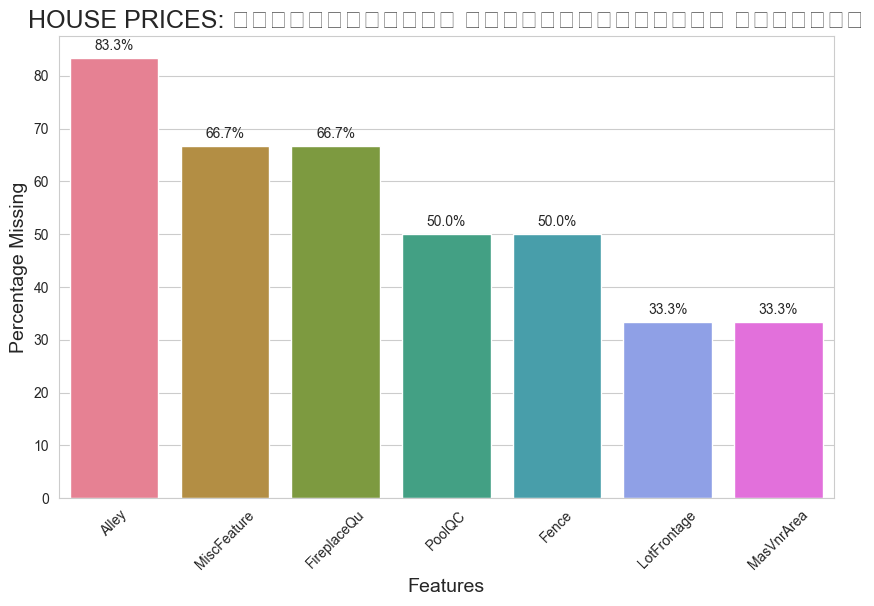

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'PoolQC': [np.nan, 'Gd', 'Ex', np.nan, 'Fa', np.nan],
    'MiscFeature': ['Shed', np.nan, 'Shed', np.nan, np.nan, np.nan],
    'Alley': [np.nan, 'Grvl', np.nan, np.nan, np.nan, np.nan],
    'Fence': ['MnPrv', np.nan, 'GdPrv', np.nan, np.nan, 'MnPrv'],
    'FireplaceQu': [np.nan, 'TA', np.nan, 'TA', np.nan, np.nan],
    'LotFrontage': [65.0, 80.0, np.nan, 60.0, 84.0, np.nan],
    'MasVnrArea': [196.0, 0.0, 0.0, 20.0, np.nan, np.nan],
    'Utilities': ['AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub', 'AllPub'],
    'CentralAir': ['Y', 'Y', 'Y', 'Y', 'Y', 'Y'],
    'Id': [1, 2, 3, 4, 5, 6]
}
df = pd.DataFrame(data)

missing_counts = df.isnull().sum()
missing_data = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({'Percentage Missing': missing_percentage})

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(x=missing_df.index, y='Percentage Missing', data=missing_df, palette="husl")

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f') + '%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.title('HOUSE PRICES:', fontsize=18)
plt.ylabel('Percentage Missing', fontsize=14)
plt.xlabel('Features', fontsize=14)
plt.xticks(rotation=45)


plt.show()

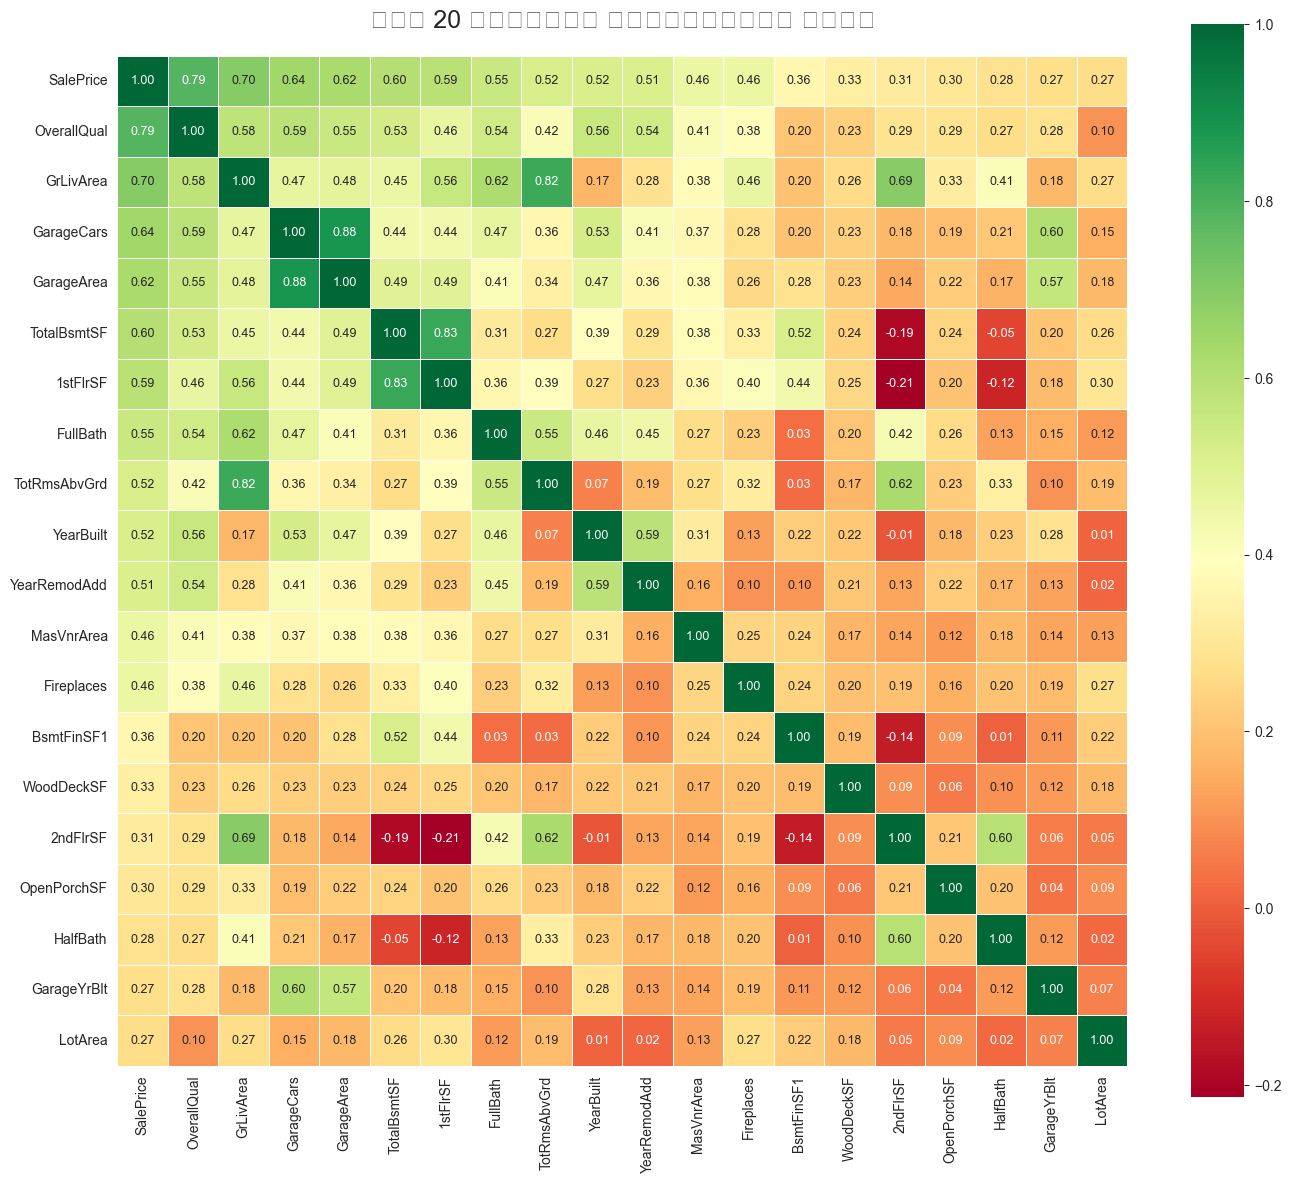

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = X_train.copy()
plot_df['SalePrice'] = y_train

numeric_df = plot_df.select_dtypes(include=['int64', 'float64'])

corrmat = numeric_df.corr()

top_20_cols = corrmat.nlargest(20, 'SalePrice')['SalePrice'].index

top_20_corr = numeric_df[top_20_cols].corr()

plt.figure(figsize=(14, 12))

sns.heatmap(
    top_20_corr, 
    annot=True,              
    fmt=".2f",              
    cmap="RdYlGn",           
    square=True,            
    linewidths=0.5,      
    annot_kws={"size": 9}    )

plt.title("top 20 peacher coleration ", fontsize=18, pad=20)

plt.xticks(rotation=90) 
plt.yticks(rotation=0) 

plt.tight_layout()
plt.show()

# Feature Engineering

In [37]:
encd_test = pd.get_dummies(test_rdr)
encd_train = pd.get_dummies(train_rdr)

y_train = encd_train['SalePrice']
encd_train = encd_train.drop('SalePrice', axis=1)

encd_train, encd_test = encd_train.align(encd_test, join='left', axis=1, fill_value=0)
encd_train['SalePrice'] = y_train

print(f"new size for train :  {encd_train.shape}")
print(f"new size for test :  {encd_test.shape}")

new size for train :  (1460, 305)
new size for test :  (1459, 304)


# Feature Selection

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

X = encd_train.drop('SalePrice', axis=1)
y = encd_train['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

with mlflow.start_run(run_name="Baseline_RandomForest"):
    
    paramtrs = {
        "n_estimators": 100,
        "random_state": 42
    }
    mlflow.log_params(paramtrs)
    rf_model = RandomForestRegressor(**paramtrs)
    rf_model.fit(X_train, y_train)
    
    val_predictions = rf_model.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(sk_model=rf_model, name="random_forest_model",serialization_format="skops")
    
    print(f"we have finished, error: {val_rmse:,.2f}")

we have finished, error: 29,510.46
🏃 View run Baseline_RandomForest at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0/runs/9b61cfd34e3842d68f6e65c14a6de9f8
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0


# Training

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

X = encd_train.drop('SalePrice', axis=1)
y = encd_train['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

with mlflow.start_run(run_name="Baseline_RandomForest"):
    
    paramtrs = {
        "n_estimators": 100,
        "random_state": 42
    }
    mlflow.log_params(paramtrs)
    rf_model = RandomForestRegressor(**paramtrs)
    rf_model.fit(X_train, y_train)
    
    val_predictions = rf_model.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(sk_model=rf_model, name="random_forest_model",serialization_format="skops")
    
    print(f"we have finished, error: {val_rmse:,.2f}")

we have finished, error: 29,510.46
🏃 View run Baseline_RandomForest at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0/runs/c524909dacdb4762a1ad2213161ec4d4
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0


In [10]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "n_estimators": [100, 200, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=10, 
    cv=3,     
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1  
)

rf_search.fit(X_train, y_train)
print(f"Best parameters found: {rf_search.best_params_}")

Best parameters found: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': None, 'max_depth': 20}


In [11]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_squared_error
import numpy as np

with mlflow.start_run(run_name="Tuned_RandomForest"):
    
    best_params = rf_search.best_params_
    mlflow.log_params(best_params)
    
    best_rf_model = rf_search.best_estimator_
    
    val_predictions = best_rf_model.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    
    mlflow.log_metric("val_rmse", val_rmse)
    mlflow.sklearn.log_model(
        sk_model=best_rf_model, 
        name="tuned_random_forest_model",
        serialization_format="skops"
    )
    
    print(f"New tuned error: {val_rmse:,.2f}")

New tuned error: 29,440.94
🏃 View run Tuned_RandomForest at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0/runs/393b0c66435544d198db274d8a639bf4
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0


In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import numpy as np

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

with mlflow.start_run(run_name="XGBoost_Baseline"):
    
    xgb_model = XGBRegressor(
        learning_rate=0.1,
        n_estimators=100,
        max_depth=5,       
        random_state=42
    )
    
    xgb_model.fit(X_train, y_train_log)
    val_predictions_log = xgb_model.predict(X_val)
    val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_predictions_log))
    mlflow.log_metric("val_rmsle", val_rmsle)
    
    mlflow.sklearn.log_model(
        sk_model=xgb_model, 
        name="xgboost_model",
        serialization_format="skops",
        skops_trusted_types=[
            "xgboost.sklearn.XGBRegressor", 
            "xgboost.core.Booster"
        ]
    )
    
    print(f"XGBoost Log-RMSE (RMSLE): {val_rmsle:.5f}")

XGBoost Log-RMSE (RMSLE): 0.14106
🏃 View run XGBoost_Baseline at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0/runs/0ae229d4e6a94f058e4ca8255fb264e2
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    "n_estimators": [100, 500, 1000],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],       
    "colsample_bytree": [0.8, 1.0] 
}
xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=15, 
    cv=3,      
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1   
)

print("Searching for best XGBoost parameters. This might take a minute...")
xgb_search.fit(X_train, y_train_log)

print(f"Best parameters found: {xgb_search.best_params_}")

Searching for best XGBoost parameters. This might take a minute...
Best parameters found: {'subsample': 1.0, 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import numpy as np

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

with mlflow.start_run(run_name="XGBoost_Tuned"):
    
    xgb_tuned_model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=3,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42
    )
    
    mlflow.log_params({
        "n_estimators": 1000,
        "learning_rate": 0.05,
        "max_depth": 3,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    })
    
    xgb_tuned_model.fit(X_train, y_train_log)
    val_predictions_log = xgb_tuned_model.predict(X_val)
    val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_predictions_log))
    
    mlflow.log_metric("val_rmsle", val_rmsle)
    
    mlflow.sklearn.log_model(
        sk_model=xgb_tuned_model, 
        name="tuned_xgboost_model",
        serialization_format="skops",
        skops_trusted_types=[
            "xgboost.sklearn.XGBRegressor", 
            "xgboost.core.Booster"
        ]
    )
    
    print(f"Tuned XGBoost Log-RMSE (RMSLE): {val_rmsle:.5f}")

Tuned XGBoost Log-RMSE (RMSLE): 0.13397
🏃 View run XGBoost_Tuned at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0/runs/473e5e7e4bc44fabb5457c9f1e5526c1
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0


In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import numpy as np

X_train_age = X_train.copy()
X_val_age = X_val.copy()

X_train_age['House_Age'] = X_train_age['YrSold'] - X_train_age['YearRemodAdd']
X_val_age['House_Age'] = X_val_age['YrSold'] - X_val_age['YearRemodAdd']

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

with mlflow.start_run(run_name="XGBoost_Tuned_Age_Feature"):
    
    xgb_age_model = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=3,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42
    )
    
    mlflow.log_params({
        "n_estimators": 1000, "learning_rate": 0.05, "max_depth": 3, 
        "subsample": 1.0, "colsample_bytree": 1.0, "feature_engineering": "House_Age"
    })
    
    xgb_age_model.fit(X_train_age, y_train_log)
    val_predictions_log = xgb_age_model.predict(X_val_age)
    
    val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_predictions_log))
    
    mlflow.log_metric("val_rmsle", val_rmsle)
    mlflow.sklearn.log_model(
        sk_model=xgb_age_model, 
        name="age_xgboost_model",
        serialization_format="skops",
        skops_trusted_types=["xgboost.sklearn.XGBRegressor", "xgboost.core.Booster"]
    )
    
    print(f"Age Engineered XGBoost Log-RMSE (RMSLE): {val_rmsle:.5f}")

Age Engineered XGBoost Log-RMSE (RMSLE): 0.13409
🏃 View run XGBoost_Tuned_Age_Feature at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0/runs/b20db52bb0cb4cdea3c933191c649214
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0


In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

rf_best = RandomForestRegressor(
    n_estimators=100, min_samples_split=2, 
    max_features=None, max_depth=20, random_state=42
)
rf_best.fit(X_train, y_train_log)
rf_preds_log = rf_best.predict(X_val)

xgb_best = XGBRegressor(
    n_estimators=1000, learning_rate=0.085, 
    max_depth=3, subsample=1.0, colsample_bytree=1.0, random_state=42
)
xgb_best.fit(X_train, y_train_log)
xgb_preds_log = xgb_best.predict(X_val)

blended_preds_log = (0.75 * xgb_preds_log) + (0.25 * rf_preds_log)
blended_rmsle = np.sqrt(mean_squared_error(y_val_log, blended_preds_log))

print(f"Blended Model Log-RMSE: {blended_rmsle:.5f}")


Blended Model Log-RMSE: 0.13114


In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

with mlflow.start_run(run_name="Linear_Regression_Baseline"):
    
    linear_model = LinearRegression()
    
    linear_model.fit(X_train, y_train_log)
    val_predictions_log = linear_model.predict(X_val)
    val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_predictions_log))
    mlflow.log_metric("val_rmsle", val_rmsle)
    
    mlflow.sklearn.log_model(
        sk_model=linear_model, 
        name="linear_model",
        serialization_format="skops"
    )
    
    print(f"Linear Regression Log-RMSE (RMSLE): {val_rmsle:.5f}")

Linear Regression Log-RMSE (RMSLE): 0.13237
🏃 View run Linear_Regression_Baseline at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0/runs/58790578e0f64913bfe8256d0327aacf
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0


In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

with mlflow.start_run(run_name="Ridge_Regression_Scaled"):
    
    ridge_model = Ridge(alpha=10.0, random_state=42)
    ridge_model.fit(X_train_scaled, y_train_log)
    
    val_predictions_log = ridge_model.predict(X_val_scaled)
    val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_predictions_log))
    
    mlflow.log_metric("val_rmsle", val_rmsle)
    mlflow.log_param("alpha", 10.0)
    mlflow.sklearn.log_model(
        sk_model=ridge_model, 
        name="ridge_model",
        serialization_format="skops"
    )
    
    print(f"Ridge Regression (Scaled) Log-RMSE: {val_rmsle:.5f}")

Ridge Regression (Scaled) Log-RMSE: 0.12538
🏃 View run Ridge_Regression_Scaled at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0/runs/0f314ae93e1744fbab1b0a57124215af
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0


In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

with mlflow.start_run(run_name="Ridge_Regression_Optimized"):
    
    alphas_to_test = np.logspace(-1, 3, 100)
    ridge_cv_model = RidgeCV(alphas=alphas_to_test, cv=5)
    ridge_cv_model.fit(X_train_scaled, y_train_log)
    
    best_alpha = ridge_cv_model.alpha_
    
    val_predictions_log = ridge_cv_model.predict(X_val_scaled)
    val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_predictions_log))
    
    mlflow.log_metric("val_rmsle", val_rmsle)
    mlflow.log_param("best_alpha", best_alpha)
    mlflow.sklearn.log_model(
        sk_model=ridge_cv_model, 
        name="optimized_ridge_model",
        serialization_format="skops"
    )
    
    print(f"Optimal Alpha Found: {best_alpha:.2f}")
    print(f"Optimized Ridge Log-RMSE: {val_rmsle:.5f}")

Optimal Alpha Found: 475.08
Optimized Ridge Log-RMSE: 0.13358
🏃 View run Ridge_Regression_Optimized at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0/runs/b2c40ed3b5ec42c1813bd59e1b34dbe4
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0


In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings

warnings.filterwarnings("ignore")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

with mlflow.start_run(run_name="Lasso_Regression_Optimized"):
    
    alphas_to_test = np.logspace(-5, -2, 100)
    lasso_cv_model = LassoCV(alphas=alphas_to_test, cv=5, random_state=42)
    
    lasso_cv_model.fit(X_train_scaled, y_train_log)
    
    best_alpha = lasso_cv_model.alpha_
    val_predictions_log = lasso_cv_model.predict(X_val_scaled)
    
    val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_predictions_log))
    features_kept = np.sum(lasso_cv_model.coef_ != 0)
    total_features = len(lasso_cv_model.coef_)
    
    mlflow.log_metric("val_rmsle", val_rmsle)
    mlflow.log_param("best_alpha", best_alpha)
    mlflow.log_metric("features_kept", features_kept)
    
    mlflow.sklearn.log_model(
        sk_model=lasso_cv_model, 
        name="lasso_model",
        serialization_format="skops"
    )
    
    print(f"Optimal Lasso Alpha: {best_alpha:.5f}")
    print(f"Features Kept: {features_kept} out of {total_features}")
    print(f"Lasso Log-RMSE: {val_rmsle:.5f}")

Optimal Lasso Alpha: 0.00705
Features Kept: 66 out of 304
Lasso Log-RMSE: 0.12802
🏃 View run Lasso_Regression_Optimized at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0/runs/33c769b9d4e542c49e7268e094e42cfd
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0


In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings

warnings.filterwarnings("ignore")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

with mlflow.start_run(run_name="ElasticNet_Optimized"):
    
    ratios_to_test = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
    
    elastic_cv_model = ElasticNetCV(l1_ratio=ratios_to_test, cv=5, random_state=42)
    
    elastic_cv_model.fit(X_train_scaled, y_train_log)
    val_predictions_log = elastic_cv_model.predict(X_val_scaled)
    
    val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_predictions_log))
    
    mlflow.log_metric("val_rmsle", val_rmsle)
    mlflow.log_param("best_l1_ratio", elastic_cv_model.l1_ratio_)
    mlflow.log_param("best_alpha", elastic_cv_model.alpha_)
    
    mlflow.sklearn.log_model(
        sk_model=elastic_cv_model, 
        name="elasticnet_model",
        serialization_format="skops"
    )
    
    print(f"Optimal L1 Ratio (Lasso/Ridge Balance): {elastic_cv_model.l1_ratio_}")
    print(f"ElasticNet Log-RMSE: {val_rmsle:.5f}")

Optimal L1 Ratio (Lasso/Ridge Balance): 0.1
ElasticNet Log-RMSE: 0.13040
🏃 View run ElasticNet_Optimized at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0/runs/a4813f8dd7ad4a7baa9d6123df0f174b
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0


In [29]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np
import joblib

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
joblib.dump(scaler, 'scaler.pkl')

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

with mlflow.start_run(run_name="Ridge_Regression_Scaled_Final"):
    
    ridge_model = Ridge(alpha=10.0, random_state=42)
    ridge_model.fit(X_train_scaled, y_train_log)
    
    val_predictions_log = ridge_model.predict(X_val_scaled)
    val_rmsle = np.sqrt(mean_squared_error(y_val_log, val_predictions_log))
    
    mlflow.log_metric("val_rmsle", val_rmsle)
    mlflow.log_param("alpha", 10.0)
    
    mlflow.log_artifact("scaler.pkl")
    
    mlflow.sklearn.log_model(
        sk_model=ridge_model, 
        artifact_path="ridge_model",
        registered_model_name="Champion_Ridge_Model" 
    )
    
    print(f"Ridge Regression (Scaled) Log-RMSE: {val_rmsle:.5f}")

2026/04/10 15:52:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 15:52:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Champion_Ridge_Model'.
2026/04/10 15:52:15 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Champion_Ridge_Model, version 1
Created version '1' of model 'Champion_Ridge_Model'.


Ridge Regression (Scaled) Log-RMSE: 0.12538
🏃 View run Ridge_Regression_Scaled_Final at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0/runs/25bdba531dc445f7b3f16dd8bbe69818
🧪 View experiment at: https://dagshub.com/kvizhmena11/ML_assignment1_house_prices.mlflow/#/experiments/0


# Feature Engineering

In [32]:
import pandas as pd

test_df = pd.read_csv('test.csv')
test_ids = test_df['Id']

X_test = test_df.drop(columns=['Id']) 
X_test = pd.get_dummies(X_test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.fillna(0)
X_test.to_pickle('X_test_cleaned.pkl')
test_ids.to_pickle('test_ids.pkl')

print("success")

success


In [33]:
import pandas as pd

X_test.to_pickle('X_test_cleaned.pkl')
test_ids.to_pickle('test_ids.pkl')

print("Cleaned test data saved successfully!")

Cleaned test data saved successfully!
